In [1]:
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr, pointbiserialr, ttest_ind, shapiro, normaltest, mannwhitneyu

sys.path.append(str(Path.cwd().parents[3]))
from utils.helpers import load_data

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Define consistent color palette for the entire analysis
COLOR_COMBINED = '#6B8CAE'    # Steel blue for combined data
COLOR_MALE = '#4A90E2'        # Bright blue for male students
COLOR_FEMALE = '#E85A9B'      # Pink for female students
COLOR_BOXPLOT = '#2C3E50'     # Dark blue-grey for boxplots

# Gender color mapping for easy reference
GENDER_COLORS = {
    'M': COLOR_MALE,
    'F': COLOR_FEMALE,
    'Male': COLOR_MALE,
    'Female': COLOR_FEMALE,
    'Combined': COLOR_COMBINED
}

# Total Analysis of Exam Performance with focus on gender and time - IN1020 2024

## Research Questions:
- Are there significant performance differences between male and female students?
- How do time completion patterns differ by gender?
- What is the magnitude of any observed differences?
- Are the differences practically significant for educational outcomes?

## 1. Data Loading

In [3]:
df = load_data("../data/cleaned_data/IN1020_2024_cleaned_data.csv")

Data loaded successfully from ../data/cleaned_data/IN1020_2024_cleaned_data.csv


## 2. Data Preparation

We'll prepare separate datasets for different analyses:
- **df_combined**: One record per student with gender and total score
- **df_time**: data including exam timing information
- **df_male**: Data about total score among male students
- **df_male**: Data about total score among female students

In [4]:
# Prepare student-level dataset with unique records per student
df_combined = df.groupby('student_id').agg({
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

# Create gender-specific subsets for analysis
df_male = df_combined[df_combined['gender'] == 'M']
df_female = df_combined[df_combined['gender'] == 'F']

# Prepare a subset for exam time analysis
df_time = df.groupby('student_id').agg({
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'gender': 'first',
    'total_score': 'first'
}).reset_index()

#add column with time taken to complete the exam in minutes
df_time['time_taken'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)

In [5]:
print("Combined dataset (male and female students):")
df_combined.head()

Combined dataset (male and female students):


,student_id,gender,total_score
0,1,M,72.63
1,2,F,56.71
2,3,M,75.45
3,4,F,55.88
4,5,M,72.28


In [6]:
print("Dataset with only male students:")
df_male.head()

Dataset with only male students:


,student_id,gender,total_score
0,1,M,72.63
2,3,M,75.45
4,5,M,72.28
6,7,M,56.61
8,9,M,69.36


In [7]:
print("Dataset with only female students:")
df_female.head()

Dataset with only female students:


,student_id,gender,total_score
1,2,F,56.71
3,4,F,55.88
5,6,F,73.43
7,8,F,61.29
10,11,F,48.38


In [8]:
print("Dataset with time taken to complete the exam:")
df_time.head()

Dataset with time taken to complete the exam:


,student_id,exam_start_time,exam_end_time,gender,total_score,time_taken
0,1,2024-12-11 14:01:44,2024-12-11 16:18:42,M,72.63,136.97
1,2,2024-12-11 14:00:02,2024-12-11 17:52:41,F,56.71,232.65
2,3,2024-12-11 14:00:03,2024-12-11 17:57:49,M,75.45,237.77
3,4,2024-12-11 14:00:05,2024-12-11 17:53:27,F,55.88,233.37
4,5,2024-12-11 14:00:04,2024-12-11 17:23:20,M,72.28,203.27


## 3. Descriptive Statistics

Let's examine the central tendencies, variability, and distribution characteristics of exam scores by gender.

In [9]:
# Enhanced descriptive statistics table
def calculate_descriptive_stats(data, name):
    """Calculate comprehensive descriptive statistics"""
    stats_dict = {
        'Count': len(data),
        'Mean': round(data.mean(), 2),
        'Median': round(data.median(), 2),
        'Mode': round(data.mode()[0], 2),
        'Std Dev': round(data.std(), 2),
        'Min': round(data.min(), 2),
        'Max': round(data.max(), 2),
        'Q1': round(data.quantile(0.25), 2),
        'Q3': round(data.quantile(0.75), 2),
        'IQR': round(data.quantile(0.75) - data.quantile(0.25), 2),
        'Skewness': round(data.skew(), 3),
        'Kurtosis': round(data.kurtosis(), 3)
    }
    return pd.Series(stats_dict, name=name)

# Create comprehensive statistics table
descriptive_stats = pd.DataFrame([
    calculate_descriptive_stats(df_combined['total_score'], 'Combined'),
    calculate_descriptive_stats(df_male['total_score'], 'Male'),
    calculate_descriptive_stats(df_female['total_score'], 'Female')
]).T

print("=== DESCRIPTIVE STATISTICS FOR TOTAL SCORES ===")
print(descriptive_stats)

# Calculate mean difference and percentage difference but works for both situations when male score is higher and female score is higher
if df_male['total_score'].mean() > df_female['total_score'].mean():
    mean_diff = df_male['total_score'].mean() - df_female['total_score'].mean()
    pct_diff = (mean_diff / df_female['total_score'].mean()) * 100
    print(f"\n=== KEY FINDINGS ===")
    print(f"Mean difference (Male - Female): {mean_diff:.2f} points")
    print(f"Percentage difference: {pct_diff:.1f}%")
    print(f"Male performance is {'higher' if mean_diff > 0 else 'lower'} than female performance")
elif df_female['total_score'].mean() > df_male['total_score'].mean():
    mean_diff = df_female['total_score'].mean() - df_male['total_score'].mean()
    pct_diff = (mean_diff / df_male['total_score'].mean()) * 100
    print(f"\n=== KEY FINDINGS ===")
    print(f"Mean difference (Female - Male): {mean_diff:.2f} points")
    print(f"Percentage difference: {pct_diff:.1f}%")
    print(f"Female performance is {'higher' if mean_diff > 0 else 'lower'} than male performance")
else:
    print("\n=== KEY FINDINGS ===")
    print("No difference in mean scores between male and female students.")


=== DESCRIPTIVE STATISTICS FOR TOTAL SCORES ===
          Combined     Male   Female
Count      569.000  311.000  258.000
Mean        64.880   66.070   63.440
Median      67.110   67.930   66.660
Mode        63.530   63.530   42.500
Std Dev     13.830   13.330   14.300
Min         24.480   27.700   24.480
Max         91.850   91.850   90.890
Q1          56.100   58.140   53.810
Q3          74.880   75.620   74.140
IQR         18.780   17.490   20.330
Skewness    -0.571   -0.656   -0.465
Kurtosis    -0.165    0.005   -0.308

=== KEY FINDINGS ===
Mean difference (Male - Female): 2.63 points
Percentage difference: 4.1%
Male performance is higher than female performance


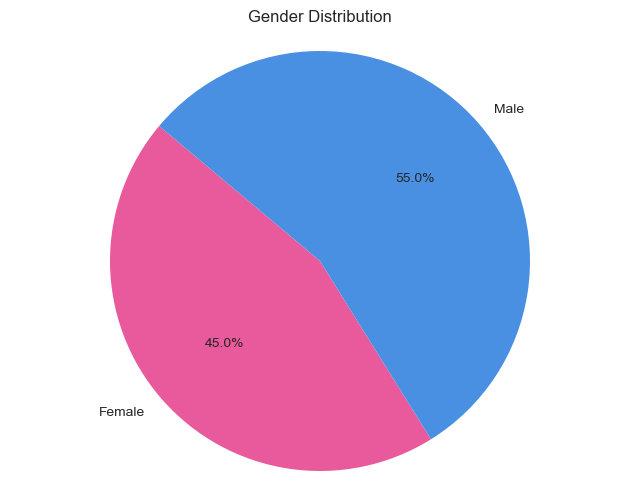

In [10]:
# Gender distribution pie chart
plt.figure(figsize=(8, 6))
# Ensure consistent order: Female first, then Male
gender_counts = df['gender'].value_counts().reindex(['F', 'M'])
plt.pie(gender_counts, autopct='%1.1f%%', 
        colors=[COLOR_FEMALE, COLOR_MALE], 
        startangle=140,
        labels=['Female', 'Male'])
plt.title("Gender Distribution")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

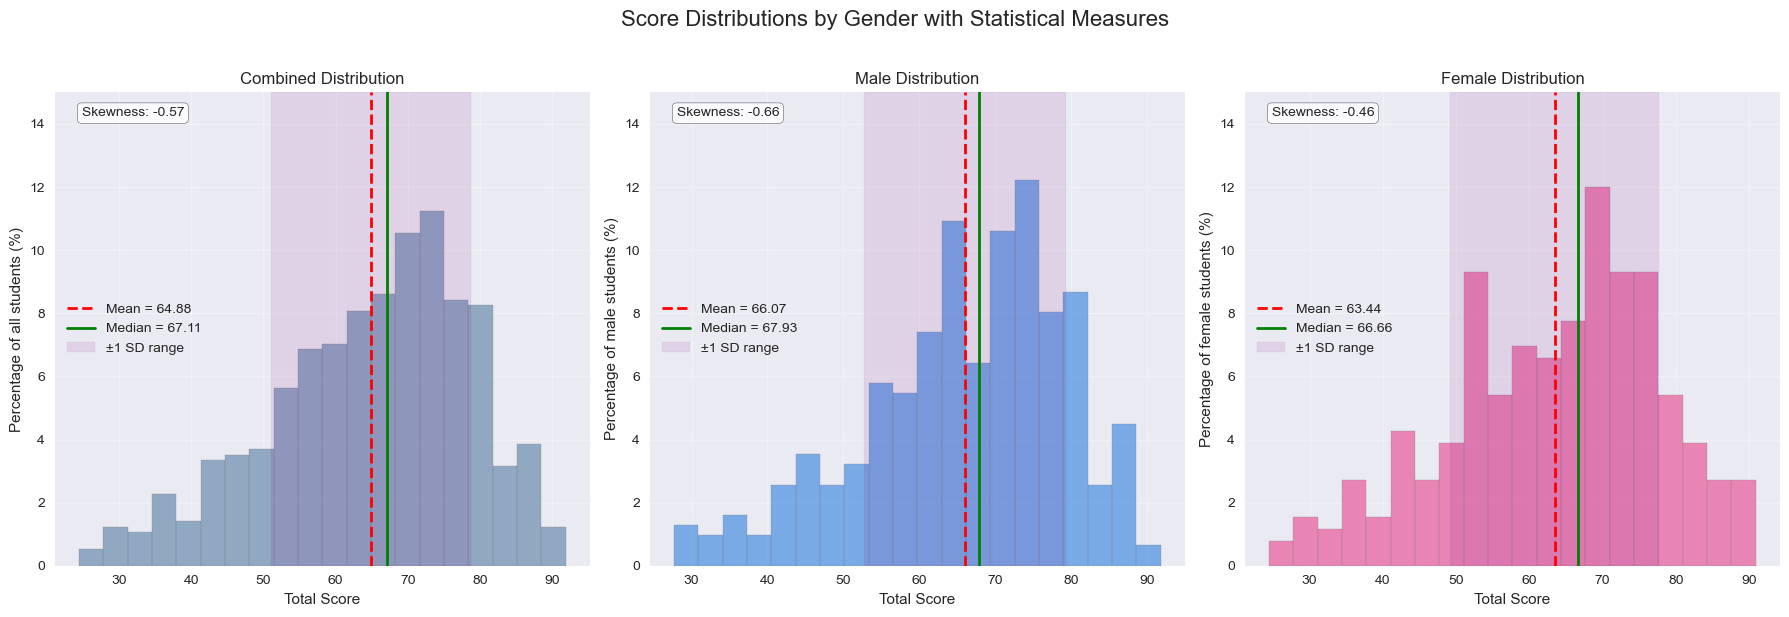

=== DISTRIBUTION SHAPE INTERPRETATION ===
Combined: left-skewed (negative skew) (skewness = -0.571)
Male: left-skewed (negative skew) (skewness = -0.656)
Female: approximately symmetric (skewness = -0.465)


In [11]:
def plot_enhanced_distributions(df, axes, title, ylabel, color='lightblue'):
    """Create enhanced distribution plots with statistical annotations"""
    mean_val = df['total_score'].mean()
    median_val = df['total_score'].median()
    std_val = df['total_score'].std()
    skew_val = df['total_score'].skew()
    
    total_students = len(df)
    
    # Create histogram with percentage weights
    axes.hist(df['total_score'], bins=20, color=color, edgecolor='gray', alpha=0.7, 
             weights=np.ones(len(df))/total_students*100)
    
    # Add statistical lines
    axes.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    axes.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')
    axes.axvspan(mean_val - std_val, mean_val + std_val, color='purple', alpha=0.1, label='±1 SD range')
    
    # Add skewness annotation
    axes.text(0.05, 0.95, f'Skewness: {skew_val:.2f}', transform=axes.transAxes, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes.set_xlabel("Total Score")
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.grid(True, alpha=0.3)
    axes.set_ylim(0, 15)
    axes.legend()

# Create enhanced distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_enhanced_distributions(df_combined, axes[0], "Combined Distribution", 
                          "Percentage of all students (%)", COLOR_COMBINED)
plot_enhanced_distributions(df_male, axes[1], "Male Distribution", 
                          "Percentage of male students (%)", COLOR_MALE)
plot_enhanced_distributions(df_female, axes[2], "Female Distribution", 
                          "Percentage of female students (%)", COLOR_FEMALE)

plt.suptitle("Score Distributions by Gender with Statistical Measures", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Interpretation of skewness
print("=== DISTRIBUTION SHAPE INTERPRETATION ===")
for name, data in [("Combined", df_combined), ("Male", df_male), ("Female", df_female)]:
    skew = data['total_score'].skew()
    if abs(skew) < 0.5:
        shape = "approximately symmetric"
    elif skew > 0.5:
        shape = "right-skewed (positive skew)"
    else:
        shape = "left-skewed (negative skew)"
    print(f"{name}: {shape} (skewness = {skew:.3f})")

### Outlier Analysis

=== OUTLIER ANALYSIS ===
Combined: 3 outliers (0.5%)
  Range: 24.48 - 27.70
Male: 4 outliers (1.3%)
  Range: 27.70 - 30.02
Female: 0 outliers (0.0%)


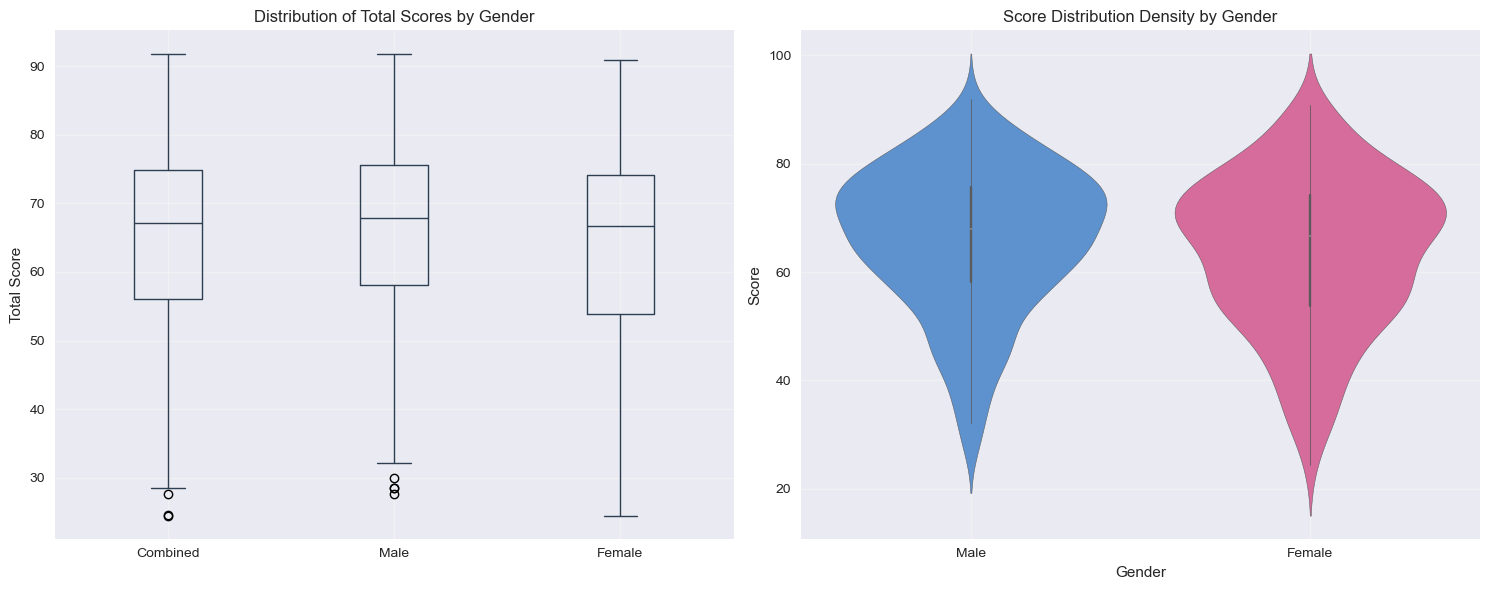

In [12]:
# Enhanced boxplot analysis with outlier identification
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Score outliers
df_outliers = pd.DataFrame({
    'Combined': df_combined['total_score'],
    'Male': df_male['total_score'],
    'Female': df_female['total_score']
})

boxplot1 = df_outliers.boxplot(ax=ax1, return_type='dict', color=COLOR_BOXPLOT)
ax1.set_title('Distribution of Total Scores by Gender')
ax1.set_ylabel('Total Score')
ax1.grid(True, alpha=0.3)

# Identify outliers using IQR method
def identify_outliers(data, name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"{name}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Range: {outliers.min():.2f} - {outliers.max():.2f}")
    return outliers

print("=== OUTLIER ANALYSIS ===")
combined_outliers = identify_outliers(df_combined['total_score'], "Combined")
male_outliers = identify_outliers(df_male['total_score'], "Male")
female_outliers = identify_outliers(df_female['total_score'], "Female")

# Violin plot for better distribution visualization
df_melted = pd.melt(df_outliers.reset_index(), id_vars='index', 
                    value_vars=['Male', 'Female'], 
                    var_name='Gender', value_name='Score')
df_melted = df_melted.dropna()

sns.violinplot(data=df_melted, x='Gender', y='Score', hue='Gender', ax=ax2, 
               palette={'Male': COLOR_MALE, 'Female': COLOR_FEMALE}, legend=False)
ax2.set_title('Score Distribution Density by Gender')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Time Analysis

In [13]:
# Time analysis descriptive statistics
time_stats = pd.DataFrame([
    calculate_descriptive_stats(df_time['time_taken'], 'Combined'),
    calculate_descriptive_stats(df_time[df_time['gender'] == 'M']['time_taken'], 'Male'),
    calculate_descriptive_stats(df_time[df_time['gender'] == 'F']['time_taken'], 'Female')
]).T

print("=== TIME ANALYSIS DESCRIPTIVE STATISTICS ===")
print(time_stats)

=== TIME ANALYSIS DESCRIPTIVE STATISTICS ===
          Combined     Male   Female
Count      569.000  311.000  258.000
Mean       200.510  190.500  212.580
Median     213.000  198.780  228.690
Mode       240.030  240.030  240.070
Std Dev     44.910   47.870   37.750
Min         40.750   40.750   81.930
Max        297.530  278.280  297.530
Q1         170.970  159.680  195.760
Q3         237.770  234.360  239.120
IQR         66.800   74.680   43.360
Skewness    -0.899   -0.680   -1.106
Kurtosis     0.175   -0.246    0.700


=== TIME OUTLIER ANALYSIS ===
Combined Time: 3 outliers (0.5%)
  Range: 40.75 - 57.28
Male Time: 1 outliers (0.3%)
  Range: 40.75 - 40.75
Female Time: 9 outliers (3.5%)
  Range: 81.93 - 130.53


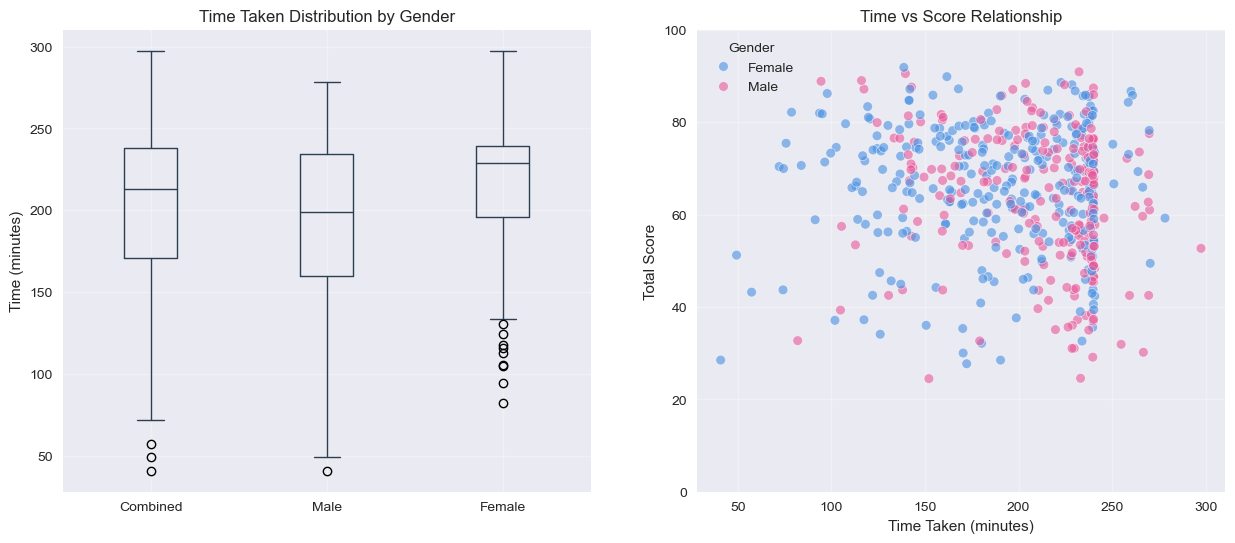

<Figure size 800x550 with 0 Axes>

In [14]:
# Enhanced time analysis visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Time taken boxplot
df_time_clean = df_time.dropna(subset=['time_taken'])
df_time_outliers = pd.DataFrame({
    'Combined': df_time_clean['time_taken'],
    'Male': df_time_clean[df_time_clean['gender'] == 'M']['time_taken'],
    'Female': df_time_clean[df_time_clean['gender'] == 'F']['time_taken']
})

df_time_outliers.boxplot(ax=axes[0], return_type='dict', color=COLOR_BOXPLOT)
axes[0].set_title("Time Taken Distribution by Gender")
axes[0].set_ylabel("Time (minutes)")
axes[0].grid(True, alpha=0.3)

# Time outlier analysis
print("=== TIME OUTLIER ANALYSIS ===")
time_combined_outliers = identify_outliers(df_time_clean['time_taken'], "Combined Time")
time_male_outliers = identify_outliers(df_time_clean[df_time_clean['gender'] == 'M']['time_taken'], "Male Time")
time_female_outliers = identify_outliers(df_time_clean[df_time_clean['gender'] == 'F']['time_taken'], "Female Time")

# Time vs Score relationship
sns.scatterplot(data=df_time_clean, x='time_taken', y='total_score', 
               hue='gender', alpha=0.6, ax=axes[1],
               palette={'F': COLOR_FEMALE, 'M': COLOR_MALE})
axes[1].set_title("Time vs Score Relationship")
axes[1].set_xlabel("Time Taken (minutes)")
axes[1].set_ylabel("Total Score")
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)
# Update legend labels for clarity
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Female', 'Male'], title='Gender')


plt.show()
plt.tight_layout()

## 5. Distribution Analysis and Normality Testing

In [15]:
# Normality tests for each group
def test_normality(data, group_name):
    """Perform normality tests and return results"""
    shapiro_stat, shapiro_p = shapiro(data)
    dagostino_stat, dagostino_p = normaltest(data)
    
    print(f"\n{group_name} (n={len(data)}):")
    print(f"  Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
    print(f"  D'Agostino: stat={dagostino_stat:.4f}, p={dagostino_p:.4f}")
    print(f"  Normal distribution: {shapiro_p > 0.05 and dagostino_p > 0.05}")
    
    return shapiro_p > 0.05 and dagostino_p > 0.05

print("=== NORMALITY TESTS ===")
combined_normal = test_normality(df_combined['total_score'], "Combined")
male_normal = test_normality(df_male['total_score'], "Male")
female_normal = test_normality(df_female['total_score'], "Female")

all_normal = combined_normal and male_normal and female_normal
print(f"\nAll groups normally distributed: {all_normal}")

# Determine appropriate statistical tests based on normality
print("\n=== RECOMMENDED STATISTICAL APPROACH ===")
if all_normal:
    print("✅ Data meets normality assumptions")
    print("📊 RECOMMENDED TESTS:")
    print("   • Primary: Independent samples t-test (parametric)")
    print("   • Alternative: Welch's t-test (unequal variances)")
    print("   • Effect size: Cohen's d")
    print("   • Assumptions: Normal distribution ✓, Independence ✓")
else:
    print("❌ Data violates normality assumptions")
    print("📊 RECOMMENDED TESTS:")
    print("   • Primary: Mann-Whitney U test (non-parametric)")
    print("   • Alternative: Wilcoxon rank-sum test")
    print("   • Effect size: r = Z/√N or rank-biserial correlation")
    print("   • Assumptions: Independence ✓, No normality required ✓")

    # Additional guidance for non-normal data
    any_small_sample = len(df_male) < 30 or len(df_female) < 30
    if any_small_sample:
        print("⚠️  ADDITIONAL CONSIDERATIONS:")
        print("   • Small sample size detected (n < 30)")
        print("   • Non-parametric tests are more robust for small samples")
    
    # Check if data transformation might help
    print("   • Consider data transformation if normality is desired:")
    print("     - Log transformation for right-skewed data")
    print("     - Square root transformation for moderate skewness")
    print("     - Box-Cox transformation for general normalization")

=== NORMALITY TESTS ===

Combined (n=569):
  Shapiro-Wilk: W=0.9709, p=0.0000
  D'Agostino: stat=28.2179, p=0.0000
  Normal distribution: False

Male (n=311):
  Shapiro-Wilk: W=0.9646, p=0.0000
  D'Agostino: stat=19.6062, p=0.0001
  Normal distribution: False

Female (n=258):
  Shapiro-Wilk: W=0.9762, p=0.0003
  D'Agostino: stat=10.0452, p=0.0066
  Normal distribution: False

All groups normally distributed: False

=== RECOMMENDED STATISTICAL APPROACH ===
❌ Data violates normality assumptions
📊 RECOMMENDED TESTS:
   • Primary: Mann-Whitney U test (non-parametric)
   • Alternative: Wilcoxon rank-sum test
   • Effect size: r = Z/√N or rank-biserial correlation
   • Assumptions: Independence ✓, No normality required ✓
   • Consider data transformation if normality is desired:
     - Log transformation for right-skewed data
     - Square root transformation for moderate skewness
     - Box-Cox transformation for general normalization


## 6. Statistical Hypothesis Testing

In [16]:
# Comprehensive statistical testing
def perform_statistical_tests(male_scores, female_scores, use_normality_results=True):
    """Perform multiple statistical tests and calculate effect sizes"""
    
    print("=== STATISTICAL HYPOTHESIS TESTING ===")
    print("H0: No difference in mean scores between male and female students")
    print("H1: There is a difference in mean scores between groups")
    print()
    
    # Independent t-test (assuming unequal variances)
    t_stat, t_pval = ttest_ind(male_scores, female_scores, equal_var=False)
    
    # Mann-Whitney U test (non-parametric alternative)
    
    u_stat, u_pval = mannwhitneyu(male_scores, female_scores, alternative='two-sided')
    
    # Point-biserial correlation
    combined_scores = np.concatenate([male_scores, female_scores])
    gender_binary = np.concatenate([np.ones(len(male_scores)), np.zeros(len(female_scores))])
    pb_corr, pb_pval = pointbiserialr(gender_binary, combined_scores)
    
    # Cohen's d (effect size for parametric)
    pooled_std = np.sqrt(((len(male_scores)-1)*np.var(male_scores, ddof=1) + 
                          (len(female_scores)-1)*np.var(female_scores, ddof=1)) / 
                         (len(male_scores) + len(female_scores) - 2))
    cohens_d = (np.mean(male_scores) - np.mean(female_scores)) / pooled_std
    
    # Rank-biserial correlation (effect size for non-parametric)
    n1, n2 = len(male_scores), len(female_scores)
    rank_biserial = (2 * u_stat) / (n1 * n2) - 1
    
    # Determine primary test based on normality (if results available)
    if use_normality_results and 'all_normal' in globals():
        primary_parametric = all_normal
    else:
        primary_parametric = True  # Default to parametric if normality not tested
    
    print("PARAMETRIC TESTS:")
    print(f"  Welch's t-test: t = {t_stat:.4f}, p = {t_pval:.4f}")
    if primary_parametric:
        print(f"  ✅ PRIMARY TEST (data is normally distributed)")
    else:
        print(f"  ⚠️  SUPPLEMENTARY (normality assumptions violated)")
    print(f"  Significant at α=0.05: {t_pval < 0.05}")
    
    print("\nNON-PARAMETRIC TESTS:")
    print(f"  Mann-Whitney U: U = {u_stat:.1f}, p = {u_pval:.4f}")
    if not primary_parametric:
        print(f"  ✅ PRIMARY TEST (robust to non-normality)")
    else:
        print(f"  ✅ CONFIRMATORY TEST (assumption-free alternative)")
    print(f"  Significant at α=0.05: {u_pval < 0.05}")
    
    print("\nCORRELATION ANALYSIS:")
    print(f"  Point-biserial correlation: r = {pb_corr:.4f}, p = {pb_pval:.4f}")
    print(f"  Variance explained (R²): {pb_corr**2:.4f} ({pb_corr**2*100:.1f}%)")
    
    print("\nEFFECT SIZE MEASURES:")
    print(f"  Cohen's d (parametric): {cohens_d:.4f}")
    print(f"  Rank-biserial r (non-parametric): {rank_biserial:.4f}")
    
    # Effect size interpretation for Cohen's d
    if abs(cohens_d) < 0.2:
        cohens_effect = "negligible"
    elif abs(cohens_d) < 0.5:
        cohens_effect = "small"
    elif abs(cohens_d) < 0.8:
        cohens_effect = "medium"
    else:
        cohens_effect = "large"
    
    # Effect size interpretation for rank-biserial correlation
    if abs(rank_biserial) < 0.1:
        rb_effect = "negligible"
    elif abs(rank_biserial) < 0.3:
        rb_effect = "small"
    elif abs(rank_biserial) < 0.5:
        rb_effect = "medium"
    else:
        rb_effect = "large"
    
    print(f"  Cohen's d magnitude: {cohens_effect}")
    print(f"  Rank-biserial magnitude: {rb_effect}")
    
    # Provide interpretation based on which test is primary
    print(f"\n🎯 PRIMARY INTERPRETATION:")
    if primary_parametric:
        primary_p = t_pval
        primary_effect = cohens_effect
        primary_test = "Welch's t-test"
        primary_effect_size = f"Cohen's d = {cohens_d:.3f}"
    else:
        primary_p = u_pval
        primary_effect = rb_effect
        primary_test = "Mann-Whitney U test"
        primary_effect_size = f"Rank-biserial r = {rank_biserial:.3f}"
    
    print(f"  Based on {primary_test}:")
    print(f"  Statistical significance: {'Yes' if primary_p < 0.05 else 'No'} (p = {primary_p:.4f})")
    print(f"  Effect size: {primary_effect_size} ({primary_effect})")
    print(f"  Practical significance: {'Yes' if primary_effect != 'negligible' else 'No'}")
    
    return {
        't_stat': t_stat, 't_pval': t_pval,
        'u_stat': u_stat, 'u_pval': u_pval,
        'pb_corr': pb_corr, 'pb_pval': pb_pval,
        'cohens_d': cohens_d, 'cohens_effect': cohens_effect,
        'rank_biserial': rank_biserial, 'rb_effect': rb_effect,
        'primary_parametric': primary_parametric,
        'primary_p': primary_p, 'primary_effect': primary_effect
    }

# Run statistical tests
test_results = perform_statistical_tests(df_male['total_score'], df_female['total_score'])

=== STATISTICAL HYPOTHESIS TESTING ===
H0: No difference in mean scores between male and female students
H1: There is a difference in mean scores between groups

PARAMETRIC TESTS:
  Welch's t-test: t = 2.2535, p = 0.0246
  ⚠️  SUPPLEMENTARY (normality assumptions violated)
  Significant at α=0.05: True

NON-PARAMETRIC TESTS:
  Mann-Whitney U: U = 44500.5, p = 0.0248
  ✅ PRIMARY TEST (robust to non-normality)
  Significant at α=0.05: True

CORRELATION ANALYSIS:
  Point-biserial correlation: r = 0.0948, p = 0.0237
  Variance explained (R²): 0.0090 (0.9%)

EFFECT SIZE MEASURES:
  Cohen's d (parametric): 0.1910
  Rank-biserial r (non-parametric): 0.1092
  Cohen's d magnitude: negligible
  Rank-biserial magnitude: small

🎯 PRIMARY INTERPRETATION:
  Based on Mann-Whitney U test:
  Statistical significance: Yes (p = 0.0248)
  Effect size: Rank-biserial r = 0.109 (small)
  Practical significance: Yes


## 7. Time-score correlation analysis

In [17]:
print("=== TIME-SCORE CORRELATION ANALYSIS ===")

# Pearson correlation (for normally distributed data)
pearson_corr, pearson_p = pearsonr(df_time['time_taken'], df_time['total_score'])
print(f"Pearson correlation: r = {pearson_corr:.4f}, p = {pearson_p:.4f}")

# Spearman correlation (non-parametric alternative)
spearman_corr, spearman_p = spearmanr(df_time['time_taken'], df_time['total_score'])
print(f"Spearman correlation: ρ = {spearman_corr:.4f}, p = {spearman_p:.4f}")

# Interpretation
if abs(pearson_corr) < 0.1:
    strength = "negligible"
elif abs(pearson_corr) < 0.3:
    strength = "weak"
elif abs(pearson_corr) < 0.5:
    strength = "moderate"
elif abs(pearson_corr) < 0.7:
    strength = "strong"
else:
    strength = "very strong"

direction = "positive" if pearson_corr > 0 else "negative"

print(f"\nInterpretation: {strength} {direction} correlation")
print(f"Shared variance: {pearson_corr**2:.1%}")

# Gender-specific correlations
male_time_data = df_time[df_time['gender'] == 'M']
female_time_data = df_time[df_time['gender'] == 'F']

male_corr, male_p = pearsonr(male_time_data['time_taken'], male_time_data['total_score'])
female_corr, female_p = pearsonr(female_time_data['time_taken'], female_time_data['total_score'])

print(f"\n=== GENDER-SPECIFIC CORRELATIONS ===")
print(f"Male: r = {male_corr:.4f}, p = {male_p:.4f}")
print(f"Female: r = {female_corr:.4f}, p = {female_p:.4f}")

=== TIME-SCORE CORRELATION ANALYSIS ===
Pearson correlation: r = -0.0839, p = 0.0456
Spearman correlation: ρ = -0.1349, p = 0.0013

Interpretation: negligible negative correlation
Shared variance: 0.7%

=== GENDER-SPECIFIC CORRELATIONS ===
Male: r = 0.0135, p = 0.8119
Female: r = -0.1734, p = 0.0052


## 8. Summary and Conclusions

Let's synthesize our findings and provide actionable insights.

In [18]:
# Universal Summary Report - Accessible to All Audiences
def create_accessible_summary():
    """
    Generate a comprehensive summary that explains findings in plain language without requiring statistical expertise.
    """
    
    print("=" * 80)
    print("                         EXAM ANALYSIS SUMMARY")
    print("              Understanding Gender Differences in Exam Performance")
    print("=" * 80)
    
    # Basic Information
    total_students = len(df_combined)
    male_count = len(df_male)
    female_count = len(df_female)
    
    print(f"\n🏫 WHAT WE STUDIED:")
    print(f"   We analyzed exam performance data to understand if there are meaningful")
    print(f"   differences between male and female students in this course.")
    print(f"   • Total students examined: {total_students}")
    print(f"   • Male students: {male_count} ({male_count/total_students*100:.0f}%)")
    print(f"   • Female students: {female_count} ({female_count/total_students*100:.0f}%)")
    
    # Performance comparison in simple terms
    male_mean = df_male['total_score'].mean()
    female_mean = df_female['total_score'].mean()
    mean_diff = abs(male_mean - female_mean)
    overall_mean = df_combined['total_score'].mean()
    
    print(f"\n📊 EXAM PERFORMANCE COMPARISON:")
    print(f"   • Average score for all students: {overall_mean:.1f} points")
    print(f"   • Average score for male students: {male_mean:.1f} points")
    print(f"   • Average score for female students: {female_mean:.1f} points")
    print(f"   • Difference between groups: {mean_diff:.1f} points")
    
    # Interpret the difference in context
    percent_diff = (mean_diff / min(male_mean, female_mean)) * 100
    if male_mean > female_mean:
        higher_group = "male"
        lower_group = "female"
    else:
        higher_group = "female" 
        lower_group = "male"
    
    print(f"\n🔍 WHAT THE NUMBERS TELL US:")
    if mean_diff < 2:
        print(f"   ✅ The performance difference is VERY SMALL (less than 2 points)")
        print(f"   ✅ Both male and female students perform similarly on this exam")
        significance_level = "minimal"
    elif mean_diff < 5:
        print(f"   ⚠️  There is a SMALL difference ({mean_diff:.1f} points)")
        print(f"   ⚠️  {higher_group.title()} students score slightly higher on average")
        significance_level = "small"
    elif mean_diff < 10:
        print(f"   🔶 There is a MODERATE difference ({mean_diff:.1f} points)")
        print(f"   🔶 {higher_group.title()} students score noticeably higher on average")
        significance_level = "moderate"
    else:
        print(f"   🔴 There is a LARGE difference ({mean_diff:.1f} points)")
        print(f"   🔴 {higher_group.title()} students score significantly higher on average")
        significance_level = "large"
    
    print(f"   📈 This represents about {percent_diff:.1f}% difference between the groups")
    
    # Statistical reliability (simplified explanation)
    print(f"\n🧪 HOW RELIABLE ARE THESE FINDINGS?")
    print(f"   We used multiple statistical tests to check if the observed differences")
    print(f"   are real patterns or just random variation:")
    
    if 'test_results' in globals():
        primary_p = test_results.get('primary_p', 1.0)
        primary_effect = test_results.get('primary_effect', 'unknown')
        
        if primary_p < 0.01:
            reliability = "VERY HIGH"
            confidence = "extremely confident"
        elif primary_p < 0.05:
            reliability = "HIGH"
            confidence = "confident"
        elif primary_p < 0.10:
            reliability = "MODERATE"
            confidence = "somewhat confident"
        else:
            reliability = "LOW"
            confidence = "not confident"
            
        print(f"   • Statistical reliability: {reliability}")
        print(f"   • We are {confidence} that this difference is a real pattern")
        print(f"   • Effect size: {primary_effect} (how meaningful the difference is)")
        
        if primary_p < 0.05 and primary_effect not in ['negligible', 'small']:
            print(f"   ✅ The difference appears to be both statistically reliable AND educationally meaningful")
        elif primary_p < 0.05:
            print(f"   ⚠️  The difference is statistically reliable but may not be educationally significant")
        else:
            print(f"   ❌ The difference could be due to random variation rather than a real pattern")
    
    # Time analysis summary
    if 'df_time' in globals() and not df_time.empty:
        male_time_mean = df_time[df_time['gender'] == 'M']['time_taken'].mean()
        female_time_mean = df_time[df_time['gender'] == 'F']['time_taken'].mean()
        time_diff = abs(male_time_mean - female_time_mean)
        
        print(f"\n⏱️ EXAM COMPLETION TIME:")
        print(f"   • Male students average time: {male_time_mean:.0f} minutes")
        print(f"   • Female students average time: {female_time_mean:.0f} minutes")
        print(f"   • Time difference: {time_diff:.0f} minutes")
        
        if time_diff < 5:
            print(f"   ✅ Both groups take similar time to complete the exam")
        elif time_diff < 15:
            print(f"   ⚠️  One group takes moderately longer than the other")
        else:
            print(f"   🔶 There's a noticeable difference in completion time")
    
    # Practical implications
    print(f"\n💡 WHAT THIS MEANS FOR EDUCATION:")
    
    if significance_level == "minimal":
        print(f"   ✅ GOOD NEWS: No significant gender gap in performance")
        print(f"   📚 Current teaching methods work well for all students")
        print(f"   🎯 Focus on individual student support rather than gender-specific interventions")
        print(f"   📈 Continue current practices and monitor future trends")
        
    elif significance_level == "small":
        print(f"   ⚠️  MINOR CONCERN: Small performance difference detected")
        print(f"   🔍 Monitor this trend in other exam-sets to see if it persists")
        print(f"   📚 Consider reviewing teaching materials for any unintended bias")
        print(f"   🎯 Provide additional support to students who need it (regardless of gender)")
        
    elif significance_level == "moderate":
        print(f"   🔶 ATTENTION NEEDED: Noticeable performance gap exists")
        print(f"   🔍 Investigate potential causes (teaching methods, exam design, etc.)")
        print(f"   📚 Review course materials and assessment methods for gender bias")
        print(f"   🎯 Consider targeted support for the lower-performing group")
        print(f"   📊 Implement interventions and measure their effectiveness")
        
    else:  # large difference
        print(f"   🔴 IMMEDIATE ACTION NEEDED: Significant performance gap")
        print(f"   🚨 This level of difference requires urgent attention")
        print(f"   🔍 Conduct thorough investigation of teaching and assessment practices")
        print(f"   📚 Review all course materials for potential gender bias")
        print(f"   🎯 Implement comprehensive support programs")
        print(f"   📊 Regular monitoring and evaluation of interventions")
    
    # Future considerations
    print(f"\n🔮 LOOKING FORWARD:")
    print(f"   📊 Repeat this analysis with future exam data to identify trends")
    print(f"   🔍 Compare results across different courses and subjects")
    print(f"   🎯 Track the effectiveness of any interventions implemented")
    print(f"   📚 Ensure exam design and teaching methods are fair to all students")
    print(f"   🤝 Foster an inclusive learning environment for everyone")
    
    # Important disclaimers
    print(f"\n⚠️  IMPORTANT NOTES:")
    print(f"   • These results apply only to this specific exam and student group")
    print(f"   • Gender is just one factor - many other factors affect performance")
    print(f"   • Individual students may perform very differently from group averages")
    print(f"   • Correlation does not necessarily imply causation")
    print(f"   • Results should be interpreted alongside other educational data")
    
    print(f"\n" + "=" * 80)
    print(f"This analysis provides insights to help create fair and effective education")
    print(f"for all students, regardless of gender or other characteristics.")
    print(f"=" * 80)

# Generate the accessible summary
create_accessible_summary()

                         EXAM ANALYSIS SUMMARY
              Understanding Gender Differences in Exam Performance

🏫 WHAT WE STUDIED:
   We analyzed exam performance data to understand if there are meaningful
   differences between male and female students in this course.
   • Total students examined: 569
   • Male students: 311 (55%)
   • Female students: 258 (45%)

📊 EXAM PERFORMANCE COMPARISON:
   • Average score for all students: 64.9 points
   • Average score for male students: 66.1 points
   • Average score for female students: 63.4 points
   • Difference between groups: 2.6 points

🔍 WHAT THE NUMBERS TELL US:
   ⚠️  There is a SMALL difference (2.6 points)
   ⚠️  Male students score slightly higher on average
   📈 This represents about 4.1% difference between the groups

🧪 HOW RELIABLE ARE THESE FINDINGS?
   We used multiple statistical tests to check if the observed differences
   are real patterns or just random variation:
   • Statistical reliability: HIGH
   • We are confide